In [65]:
# Sales_Transaction_Project_Analysis

<div style="background: linear-gradient(to right, #a18cd1, #fbc2eb); padding: 20px; border-radius: 10px; 
            font-size: 20px; font-family: 'Times New Roman'; text-align: center;">
  <h1 style="color: black;"><strong>Sales Transactions Analysis</strong></h1>
</div>

<img src="sales.jpg" class="img-fluid" alt="Sales Interior View">

<div style="background: linear-gradient(to right, #4facfe, #00f2fe); padding: 20px; border-radius: 10px; 
            font-size: 20px; font-family: 'Times New Roman'; text-align: center;">
  <h1 style="color: black;"><strong>Exploring Sales Data</strong></h1>
</div>

In [66]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [67]:
sales_data = pd.read_csv("D:\Jason\Python\e-commerce-business-transaction-analysis\Sales_Transaction.csv")

In [68]:
sales_data

,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country
0,581482,12-09-19,22485,Set Of 2 Wooden Market Crates,21.47,12,17490.0,United Kingdom
1,581475,12-09-19,22596,Christmas Star Wish List Chalkboard,10.65,36,13069.0,United Kingdom
2,581475,12-09-19,23235,Storage Tin Vintage Leaf,11.53,12,13069.0,United Kingdom
3,581475,12-09-19,23272,Tree T-Light Holder Willie Winkie,10.65,12,13069.0,United Kingdom
4,581475,12-09-19,23239,Set Of 4 Knick Knack Tins Poppies,11.94,6,13069.0,United Kingdom
...,...,...,...,...,...,...,...,...
536345,C536548,12-01-18,22168,Organiser Wood Antique White,18.96,-2,12472.0,Germany
536346,C536548,12-01-18,21218,Red Spotty Biscuit Tin,14.09,-3,12472.0,Germany
536347,C536548,12-01-18,20957,Porcelain Hanging Bell Small,11.74,-1,12472.0,Germany
536348,C536548,12-01-18,22580,Advent Calendar Gingham Sack,16.35,-4,12472.0,Germany


In [69]:
sales_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 536350 entries, 0 to 536349
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   TransactionNo  536350 non-null  object 
 1   Date           536350 non-null  object 
 2   ProductNo      536350 non-null  object 
 3   ProductName    536350 non-null  object 
 4   Price          536350 non-null  float64
 5   Quantity       536350 non-null  int64  
 6   CustomerNo     536295 non-null  float64
 7   Country        536350 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 32.7+ MB


In [70]:
sales_data.describe()

,Price,Quantity,CustomerNo
count,536350.000000,536350.000000,536295.000000
mean,12.662182,9.919347,15227.893178
std,8.490450,216.662300,1716.582932
min,5.130000,-80995.000000,12004.000000
25%,10.990000,1.000000,13807.000000
50%,11.940000,3.000000,15152.000000
75%,14.090000,10.000000,16729.000000
max,660.620000,80995.000000,18287.000000


In [71]:
sales_data.shape

(536350, 8)

<div style="background: linear-gradient(to right, #4facfe, #00f2fe); padding: 20px; border-radius: 10px; 
            font-size: 20px; font-family: 'Times New Roman'; text-align: center;">
  <h1 style="color: black;"><strong>Removing Null Values And Doing Some EDA</strong></h1>
</div>

In [72]:
sales_data.isna().sum()

TransactionNo     0
Date              0
ProductNo         0
ProductName       0
Price             0
Quantity          0
CustomerNo       55
Country           0
dtype: int64

In [73]:
sales_data["Date"] = pd.to_datetime(sales_data["Date"])

In [74]:
sales_data.dropna(how = "any" , inplace = True)

In [75]:
sales_data

,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country
0,581482,2019-12-09,22485,Set Of 2 Wooden Market Crates,21.47,12,17490.0,United Kingdom
1,581475,2019-12-09,22596,Christmas Star Wish List Chalkboard,10.65,36,13069.0,United Kingdom
2,581475,2019-12-09,23235,Storage Tin Vintage Leaf,11.53,12,13069.0,United Kingdom
3,581475,2019-12-09,23272,Tree T-Light Holder Willie Winkie,10.65,12,13069.0,United Kingdom
4,581475,2019-12-09,23239,Set Of 4 Knick Knack Tins Poppies,11.94,6,13069.0,United Kingdom
...,...,...,...,...,...,...,...,...
536345,C536548,2018-12-01,22168,Organiser Wood Antique White,18.96,-2,12472.0,Germany
536346,C536548,2018-12-01,21218,Red Spotty Biscuit Tin,14.09,-3,12472.0,Germany
536347,C536548,2018-12-01,20957,Porcelain Hanging Bell Small,11.74,-1,12472.0,Germany
536348,C536548,2018-12-01,22580,Advent Calendar Gingham Sack,16.35,-4,12472.0,Germany


In [76]:
sales_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 536295 entries, 0 to 536349
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   TransactionNo  536295 non-null  object        
 1   Date           536295 non-null  datetime64[ns]
 2   ProductNo      536295 non-null  object        
 3   ProductName    536295 non-null  object        
 4   Price          536295 non-null  float64       
 5   Quantity       536295 non-null  int64         
 6   CustomerNo     536295 non-null  float64       
 7   Country        536295 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 36.8+ MB


In [77]:
sales_data.drop(sales_data[sales_data["Date"].dt.year != 2019].index ,inplace=True)

In [78]:
sales_data = sales_data[sales_data["Quantity"] > 0]

<div style="background: linear-gradient(to right, #a18cd1, #fbc2eb); padding: 20px; border-radius: 10px; 
            font-size: 20px; font-family: 'Times New Roman'; text-align: center;">
  <h1 style="color: black;"><strong>Information About the Dataset</strong></h1>
</div>

In [79]:
sales_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 486347 entries, 0 to 494247
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   TransactionNo  486347 non-null  object        
 1   Date           486347 non-null  datetime64[ns]
 2   ProductNo      486347 non-null  object        
 3   ProductName    486347 non-null  object        
 4   Price          486347 non-null  float64       
 5   Quantity       486347 non-null  int64         
 6   CustomerNo     486347 non-null  float64       
 7   Country        486347 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.4+ MB


In [80]:
sales_data.describe()

,Date,Price,Quantity,CustomerNo
count,486347,486347.000000,486347.000000,486347.000000
mean,2019-07-21 19:14:25.922478848,12.504328,10.758948,15221.218722
min,2019-01-04 00:00:00,5.130000,1.000000,12004.000000
25%,2019-04-26 00:00:00,10.920000,1.000000,13812.000000
50%,2019-08-07 00:00:00,11.940000,4.000000,15129.000000
75%,2019-10-25 00:00:00,14.090000,12.000000,16728.000000
max,2019-12-09 00:00:00,660.620000,80995.000000,18287.000000
std,NaN,7.545024,162.966670,1713.064701


In [81]:
sales_data["Country"].value_counts().head(10)

Country
United Kingdom    439912
France              9826
Germany             9244
EIRE                7387
Spain               2327
Netherlands         2256
Switzerland         2218
Belgium             1825
Portugal            1728
Australia           1599
Name: count, dtype: int64

<div style="background: linear-gradient(to right, #a18cd1, #fbc2eb); padding: 20px; border-radius: 10px; 
            font-size: 20px; font-family: 'Times New Roman'; text-align: center;">
  <h1 style="color: black;"><strong>United Kingdom (UK) Sales Transactions Analysis</strong></h1>
</div>

In [82]:
uk_data = sales_data.query("Country == 'United Kingdom'").loc[:,["TransactionNo","Date","ProductNo","ProductName","Price","Quantity","CustomerNo","Country"]]

In [83]:
uk_data["Revenue"] = (uk_data["Price"] * uk_data["Quantity"])

In [84]:
uk_data

,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country,Revenue
0,581482,2019-12-09,22485,Set Of 2 Wooden Market Crates,21.47,12,17490.0,United Kingdom,257.64
1,581475,2019-12-09,22596,Christmas Star Wish List Chalkboard,10.65,36,13069.0,United Kingdom,383.40
2,581475,2019-12-09,23235,Storage Tin Vintage Leaf,11.53,12,13069.0,United Kingdom,138.36
3,581475,2019-12-09,23272,Tree T-Light Holder Willie Winkie,10.65,12,13069.0,United Kingdom,127.80
4,581475,2019-12-09,23239,Set Of 4 Knick Knack Tins Poppies,11.94,6,13069.0,United Kingdom,71.64
...,...,...,...,...,...,...,...,...,...
494243,540043,2019-01-04,22776,Sweetheart 3 Tier Cake Stand,20.45,1,15164.0,United Kingdom,20.45
494244,540060,2019-01-04,22968,Rose Cottage Keepsake Box,20.45,4,14732.0,United Kingdom,81.80
494245,540094,2019-01-04,22782,Set 3 Wicker Storage Baskets,20.45,4,14221.0,United Kingdom,81.80
494246,540096,2019-01-04,22782,Set 3 Wicker Storage Baskets,20.45,4,13253.0,United Kingdom,81.80


In [85]:
uk_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 439912 entries, 0 to 494247
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   TransactionNo  439912 non-null  object        
 1   Date           439912 non-null  datetime64[ns]
 2   ProductNo      439912 non-null  object        
 3   ProductName    439912 non-null  object        
 4   Price          439912 non-null  float64       
 5   Quantity       439912 non-null  int64         
 6   CustomerNo     439912 non-null  float64       
 7   Country        439912 non-null  object        
 8   Revenue        439912 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 33.6+ MB


In [86]:
uk_data.describe()

,Date,Price,Quantity,CustomerNo,Revenue
count,439912,439912.000000,439912.000000,439912.000000,4.399120e+05
mean,2019-07-22 12:10:09.045445632,12.489147,9.909423,15435.604257,1.107294e+02
min,2019-01-04 00:00:00,5.130000,1.000000,12004.000000,5.130000e+00
25%,2019-04-26 00:00:00,10.850000,1.000000,14096.000000,1.618000e+01
50%,2019-08-07 00:00:00,11.940000,3.000000,15434.000000,3.884000e+01
75%,2019-10-26 00:00:00,14.090000,10.000000,16827.000000,1.090000e+02
max,2019-12-09 00:00:00,660.620000,80995.000000,18287.000000,1.002718e+06
std,NaN,7.507366,170.700169,1620.894037,2.016842e+03


In [87]:
uk_data.shape

(439912, 9)

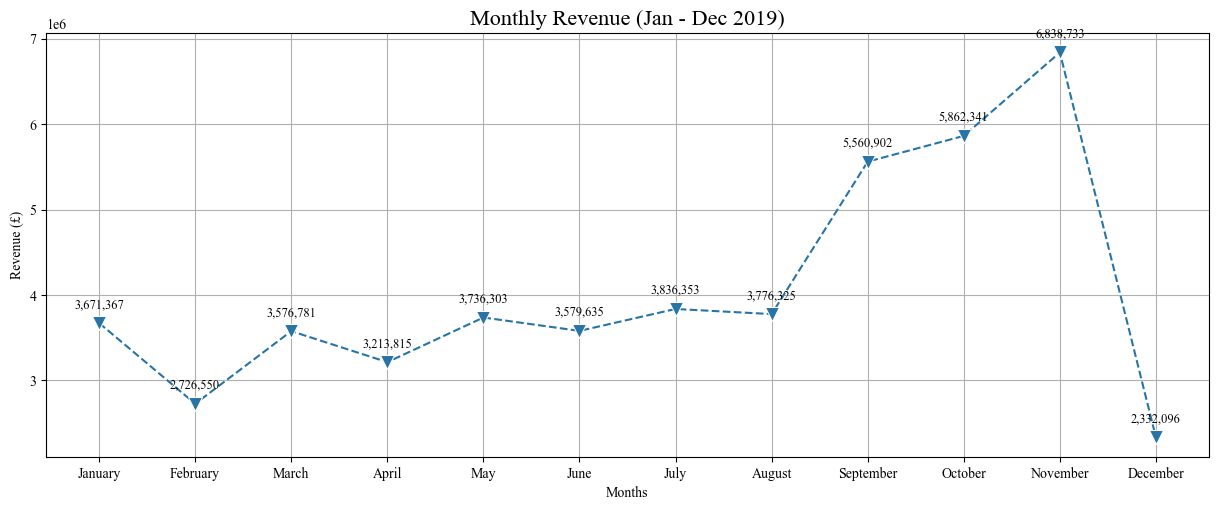

In [88]:
# 1. Revenue throughout 2019

plt.figure(figsize=(15,5.5))
plt.rcParams["font.family"] = "Times New Roman"

monthly_sales = (uk_data[uk_data["Date"].dt.year == 2019].resample('M', on = "Date")["Revenue"].sum())

sns.lineplot(x = monthly_sales.index.strftime('%B') , y = monthly_sales.values , color = "#2874A6", 
             linewidth = 1.5 , linestyle="--" , marker='v' , markersize = 10)

for x, y in zip(monthly_sales.index.strftime('%B'), monthly_sales.values):
    plt.text(x, y + (max(monthly_sales.values) * 0.02), f"{y:,.0f}", ha='center', va='bottom', fontsize = 9)

plt.xlabel("Months")
plt.ylabel("Revenue (£)")
plt.title("Monthly Revenue (Jan - Dec 2019)" ,fontsize = 16)
plt.grid()
plt.show()

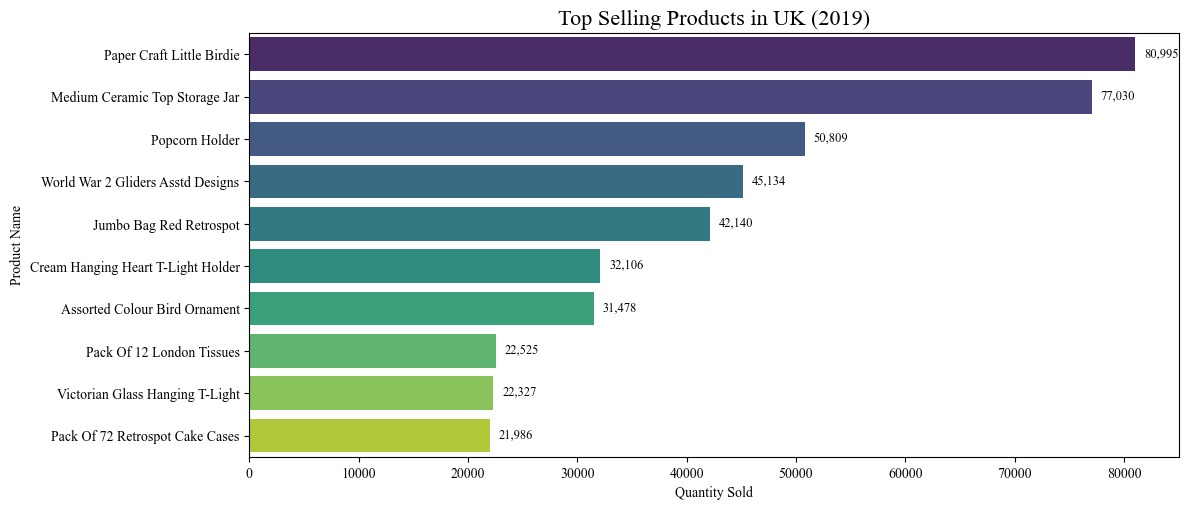

In [89]:
# 2. Top 10 selling product in UK

plt.figure(figsize=(12,5.5))
plt.rcParams["font.family"] = "Times New Roman"

top_product_uk = uk_data.groupby("ProductName")["Quantity"].sum().sort_values(ascending=False).head(10)

sns.barplot(x = top_product_uk.values, y = top_product_uk.index, palette = "viridis")

for qty, product in zip(top_product_uk.values, top_product_uk.index):
    plt.text(qty + (max(top_product_uk.values) * 0.01), product, f"{qty:,.0f}", va='center', fontsize = 9)
    
plt.xlabel("Quantity Sold")
plt.ylabel("Product Name")
plt.title("Top Selling Products in UK (2019)", fontsize = 16)
plt.show()

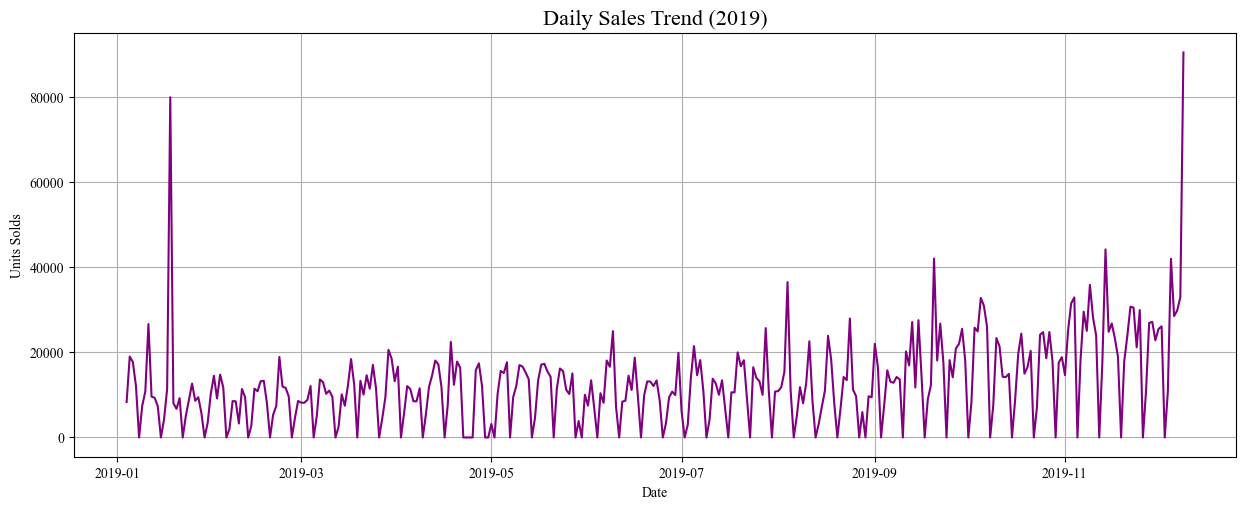

In [90]:
# 3. Sales trends over time

plt.figure(figsize=(15,5.5))
plt.rcParams["font.family"] = "Times New Roman"

daily_sales = uk_data.resample('D', on = "Date")["Quantity"].sum()

sns.lineplot(x = daily_sales.index, y = daily_sales.values, color = "purple")

plt.xlabel("Date")
plt.ylabel("Units Solds")
plt.title("Daily Sales Trend (2019)", fontsize = 16)
plt.grid()
plt.show()

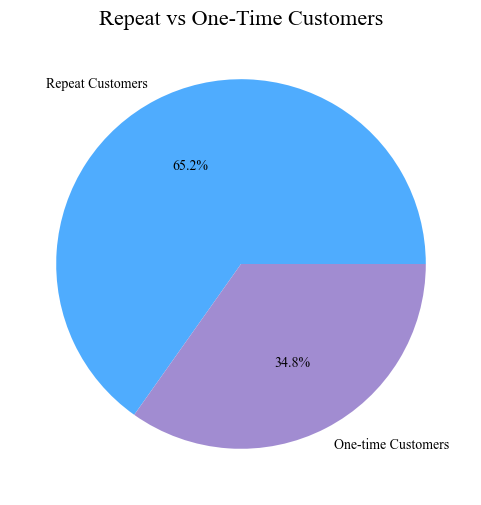

In [91]:
# 4. Repeat vs One-Time Customers

plt.figure(figsize=(6, 6))
plt.rcParams["font.family"] = "Times New Roman"

cust_orders = uk_data.groupby("CustomerNo")["TransactionNo"].nunique()
repeat_count = (cust_orders > 1).sum()
onetime_count = (cust_orders == 1).sum()

plt.pie([repeat_count, onetime_count],
        labels=["Repeat Customers", "One-time Customers"],
        autopct="%1.1f%%",
        colors=["#4facfe", "#a18cd1"])

plt.title("Repeat vs One-Time Customers", fontsize = 16)
plt.show()

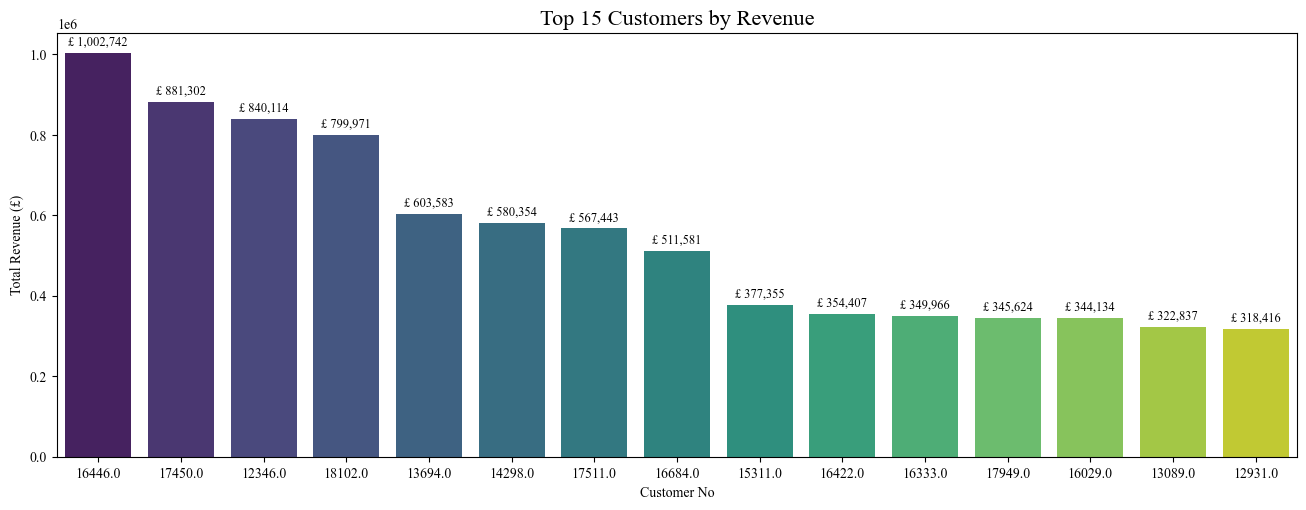

In [92]:
# 5. Top 15 customers by revenue in UK

plt.figure(figsize=(16,5.5))
plt.rcParams["font.family"] = "Times New Roman"

customer_revenue = uk_data.groupby("CustomerNo")["Revenue"].sum().sort_values(ascending = False).head(15)

ax = sns.barplot(x = customer_revenue.index , y = customer_revenue.values, order = customer_revenue.index, palette = "viridis")

for i, y in enumerate(customer_revenue.values):
    ax.text(i, y + (max(customer_revenue.values) * 0.01),f"£{y: ,.0f}", ha='center', va='bottom', fontsize = 9)

plt.title('Top 15 Customers by Revenue', fontsize = 16)
plt.xlabel('Customer No')
plt.ylabel('Total Revenue (£)')
plt.show()

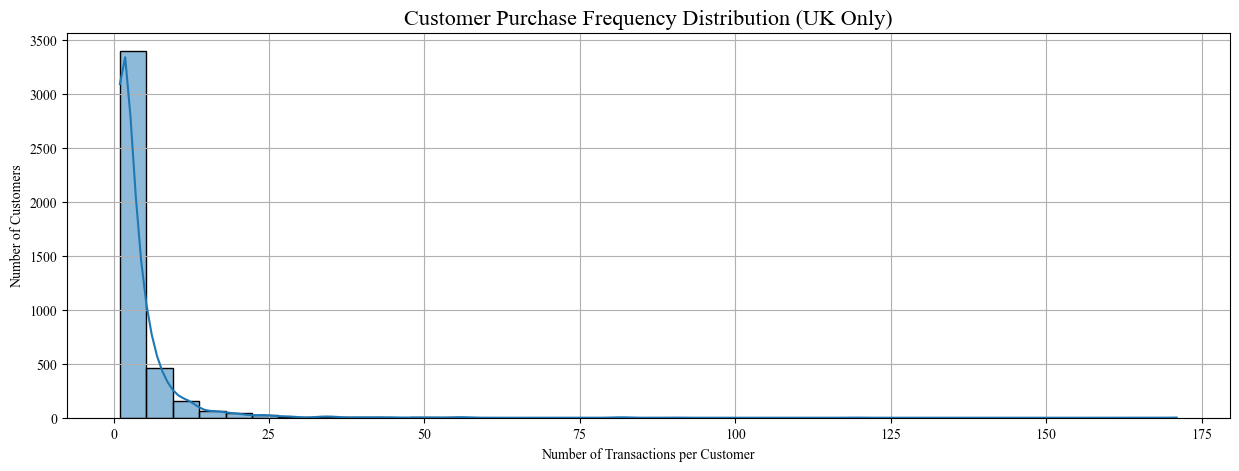

In [93]:
# 6. Purchase frequency (unique transactions per customer)

plt.figure(figsize=(15,5))
plt.rcParams["font.family"] = "Times New Roman"

purchase_freq = uk_data.groupby("CustomerNo")["TransactionNo"].nunique()

sns.histplot(purchase_freq, bins = 40, kde = True)

plt.xlabel("Number of Transactions per Customer")
plt.ylabel("Number of Customers")
plt.title("Customer Purchase Frequency Distribution (UK Only)", fontsize = 16)
plt.grid()
plt.show()

<div style="background: linear-gradient(to right, #4facfe, #00f2fe); padding: 20px; border-radius: 10px; 
            font-size: 20px; font-family: 'Times New Roman'; text-align: center;">
  <h1 style="color: black;"><strong>Final Insights</strong></h1>
</div>

<div style="font-family: 'Times New Roman'; text-align: left;">
1. A large share of revenue is driven by a small set of top products and loyal customers.Seasonal peaks exist,indicating high-demand periods (likely holidays or festivals)<br>
2. Certain products consistently dominate sales, making them crucial for stock planning and promotions.Low-selling products may be tying up resources.<br>
3. Repeat customers generate significantly higher revenue compared to one-time buyers.The UK contributes the most to sales, showing market familiarity and loyalty.<br>
4. Popular products tend to be in the low-to-mid price range but sell in higher quantities.Premium products sell less frequently but bring higher margin per unit.<br>
5. Daily/Monthly sales trends show fluctuations with noticeable spikes (holiday seasons).Weekday vs weekend differences suggest promotions should be timed strategically.<br>
6. Revenue is strongly driven by quantity, but also influenced by pricing strategies.Discounts and bulk purchases likely fuel high-volume sales.
</div>

<div style="background: linear-gradient(to right, #4facfe, #00f2fe); padding: 20px; border-radius: 10px; 
            font-size: 20px; font-family: 'Times New Roman'; text-align: center;">
  <h1 style="color: black;"><strong>Recommendations</strong></h1>
</div>

<div style="font-family: 'Times New Roman'; text-align: left;">
1. Keep higher stock levels for the top-selling products during peak months.Reduce or phase out persistently low-performing items.<br>
2. Introduce loyalty rewards, referral benefits, or subscription models for repeat buyers.Personalize offers for high-value customers.<br>
3. Focus discounts on bulk purchases of mid-range products to drive volume.Premium items can be marketed with exclusivity rather than discounts.<br>
4. Since the UK dominates sales, explore scaling into similar English-speaking or culturally aligned markets (e.g., Ireland, Canada, Australia).<br>
5. Run targeted campaigns during festive/holiday seasons when sales spike.Off-season bundles and promotions can stabilize revenue.<br>
6. Implement real-time dashboards for tracking product performance and revenue by customer.Set up anomaly detection to catch unusual dips or spikes quickly.
</div>